In [161]:
import numpy as np
from astropy.timeseries import LombScargle
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
from scipy.signal import hilbert
from scipy.optimize import curve_fit

# Cargar datos
data = np.loadtxt("SEMANA.12/T.TAURI.TESS/TIC_264739351.dat")

t = data[:, 0]
f = data[:, 1]

In [162]:
# Quitar media
f = f - np.mean(f)

In [163]:
# Rango de frecuencias
f_min = 1 / 23    # periodo máximo 100 días
f_max = 1 / 0.1   # periodo mínimo 0.1 días

frequency, power = LombScargle(t, f).autopower(
    minimum_frequency=f_min,
    maximum_frequency=f_max,
    samples_per_peak=10
)

In [164]:
best_freq = frequency[np.argmax(power)]
best_period = 1 / best_freq

print("Periodo dominante:", best_period, "días")

Periodo dominante: 2.2090689280901876 días


Text(0.5, 1.0, 'Estrella')

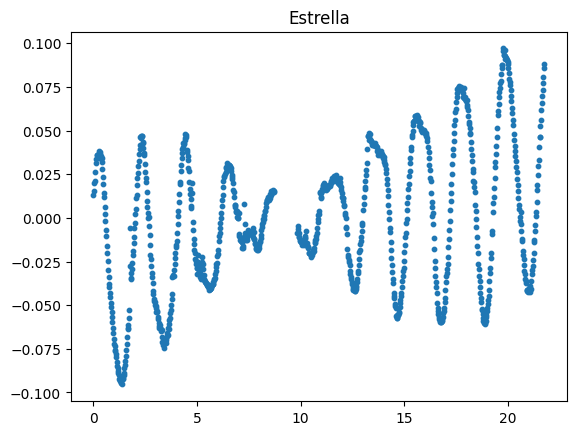

In [165]:
plt.scatter(t, f, s=10)
plt.title("Estrella")

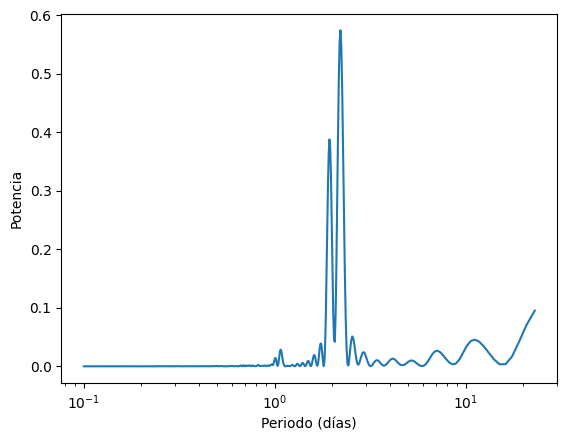

In [166]:
plt.plot(1/frequency, power)
plt.xlabel("Periodo (días)")
plt.ylabel("Potencia")
plt.xscale("log")  # útil para ver mejor
#plt.gca().invert_xaxis()  # opcional (periodos grandes a la derecha)
plt.show()

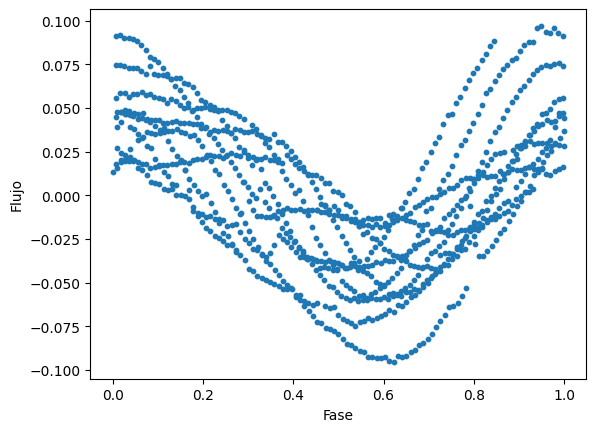

In [167]:
phase = (t % best_period) / best_period

plt.scatter(phase, f, s=10)
plt.xlabel("Fase")
plt.ylabel("Flujo")
plt.show()

In [168]:
# 1. Calcular la envolvente real con Hilbert
analytic_signal = hilbert(f)
envolvente = np.abs(analytic_signal)

# (opcional pero MUY recomendable) suavizar la envolvente

envolvente_suave = gaussian_filter1d(envolvente, sigma=10)

# Modifica la función del modelo para que sea una oscilación 
# sobre un valor medio que mantenga la curva por encima de los datos.
def modelo_envolvente(t, amp, periodo, fase, offset):
    # La envolvente física siempre debe ser > 0 para que tenga sentido 
    # como multiplicador de amplitud.
    return amp * np.sin(2 * np.pi * t / periodo + fase) + offset

# 3. Mejores estimaciones iniciales
guess_amp = 0.5 * (np.max(envolvente_suave) - np.min(envolvente_suave))
guess_offset = np.mean(envolvente_suave)

freq_env, power_env = LombScargle(t, envolvente_suave).autopower(
    minimum_frequency=1/100,
    maximum_frequency=1/5,
    samples_per_peak=20
)

guess_period = 1 / freq_env[np.argmax(power_env)]
guess_fase = 0

# 4. Ajuste sobre TODA la envolvente (no solo picos)
popt, pcov = curve_fit(
    modelo_envolvente,
    t,
    envolvente_suave,
    p0=[guess_amp, guess_period, guess_fase, guess_offset],
    maxfev=10000
)

amp_fit, per_fit, fase_fit, offset_fit = popt

print(f"Periodo de envolvente ajustado: {per_fit:.2f} días")

Periodo de envolvente ajustado: 18.17 días


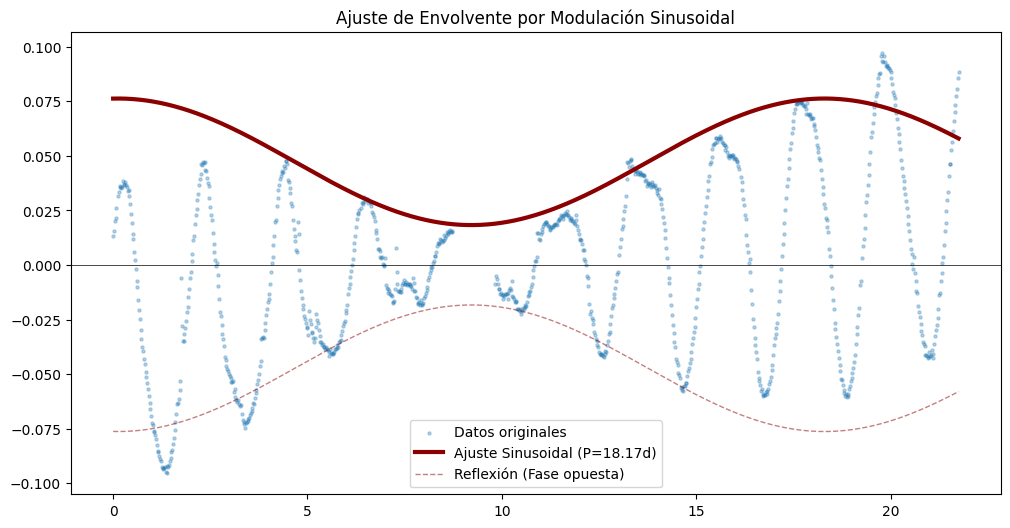

In [169]:
# 4. Visualización
t_plot = np.linspace(t.min(), t.max(), 1000)
env_ajustada = modelo_envolvente(t_plot, *popt)

plt.figure(figsize=(12, 6))
plt.scatter(t, f, s=5, alpha=0.3, label="Datos originales")
plt.plot(t_plot, env_ajustada, color='darkred', lw=3, label=f"Ajuste Sinusoidal (P={per_fit:.2f}d)")
plt.plot(t_plot, -env_ajustada, color='darkred', ls='--', lw=1, alpha=0.5, label="Reflexión (Fase opuesta)")

plt.axhline(0, color='black', lw=0.5)
plt.title("Ajuste de Envolvente por Modulación Sinusoidal")
plt.legend()
plt.show()

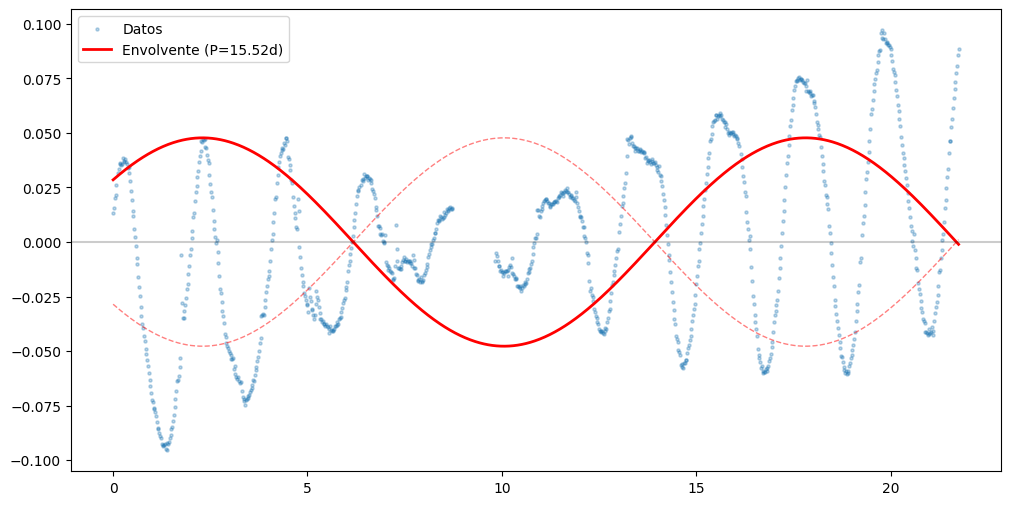

In [170]:
# 1. Definimos el modelo de Modulación de Amplitud
# f(t) = A_mod * sin(w_mod * t + phi_mod) * sin(w_fast * t + phi_fast)
def modelo_am(t, amp_m, per_m, fase_m, per_f, fase_f):
    modulacion = amp_m * np.sin(2 * np.pi * t / per_m + fase_m)
    portadora = np.sin(2 * np.pi * t / per_f + fase_f)
    return modulacion * portadora

# 2. Estimaciones iniciales (Basadas en tu gráfico)
# El periodo rápido parece ser ~2.5 días
# El periodo de la envolvente (donde se cruza) parece ser ~18 días
guess_per_fast = best_period  # El que ya encontraste con Lomb-Scargle
guess_per_mod = 20.0          # Valor visual del cruce

p0 = [np.max(f), guess_per_mod, 0, guess_per_fast, 0]

# 3. Ajuste
popt, _ = curve_fit(modelo_am, t, f, p0=p0)

# 4. Resultados para la envolvente
amp_m, per_m, fase_m, per_f, fase_f = popt
t_plot = np.linspace(t.min(), t.max(), 1000)
envolvente_superior = amp_m * np.sin(2 * np.pi * t_plot / per_m + fase_m)

plt.figure(figsize=(12, 6))
plt.scatter(t, f, s=5, alpha=0.3, label="Datos")
plt.plot(t_plot, envolvente_superior, 'r', lw=2, label=f"Envolvente (P={per_m:.2f}d)")
plt.plot(t_plot, -envolvente_superior, 'r--', lw=1, alpha=0.5)
plt.axhline(0, color='black', alpha=0.2)
plt.legend()
plt.show()

In [171]:
from numba import njit
@njit("f8[:](f8[:],f8[:],f8,f8,f8)",fastmath=True)
def NUDFT_grid(t_arg,m_arg,f_ini,f_end,df):
    """Non-Uniform Discrete Fourier Transform on an evenly-spaced frequency grid with the Kurtz (1985, MNRAS 213,773) algorithm"""
    dF = np.exp(-2j*np.pi*t_arg*df)
    F = np.zeros_like(np.arange(f_ini,f_end,df))
    curl = m_arg * np.exp(-2j*np.pi*t_arg*f_ini)
    F[0] = np.abs(np.sum(curl))**2
    for i in range(1,len(F)):
        curl = curl*dF
        F[i] = np.abs(np.sum(curl))**2
    return F

In [172]:
f_ini = 1/50
f_end = 1/0.2
df = 1e-4

F = NUDFT_grid(t, f, f_ini, f_end, df)
freqs = np.arange(f_ini, f_end, df)

idx_max = np.argmax(F)
f1 = freqs[idx_max]
P1 = 1 / f1

print("Periodo 1:", P1) 

Periodo 1: 2.206531332744938


In [173]:
def modelo_seno(t, A, B, omega):
    return A*np.sin(omega*t) + B*np.cos(omega*t)

omega1 = 2*np.pi*f1

popt, _ = curve_fit(
    lambda t, A, B: modelo_seno(t, A, B, omega1),
    t, f
)

A1, B1 = popt
modelo1 = modelo_seno(t, A1, B1, omega1)

residual = f - modelo1

In [174]:
F2 = NUDFT_grid(t, residual, f_ini, f_end, df)
idx2 = np.argmax(F2)
f2 = freqs[idx2]
P2 = 1 / f2

print("Periodo 2:", P2)

Periodo 2: 1.9523623584537404


In [175]:
omega2 = 2*np.pi*f2

popt2, _ = curve_fit(
    lambda t, A, B: modelo_seno(t, A, B, omega2),
    t, residual
)

A2, B2 = popt2
modelo2 = modelo_seno(t, A2, B2, omega2)

modelo_total = modelo1 + modelo2    

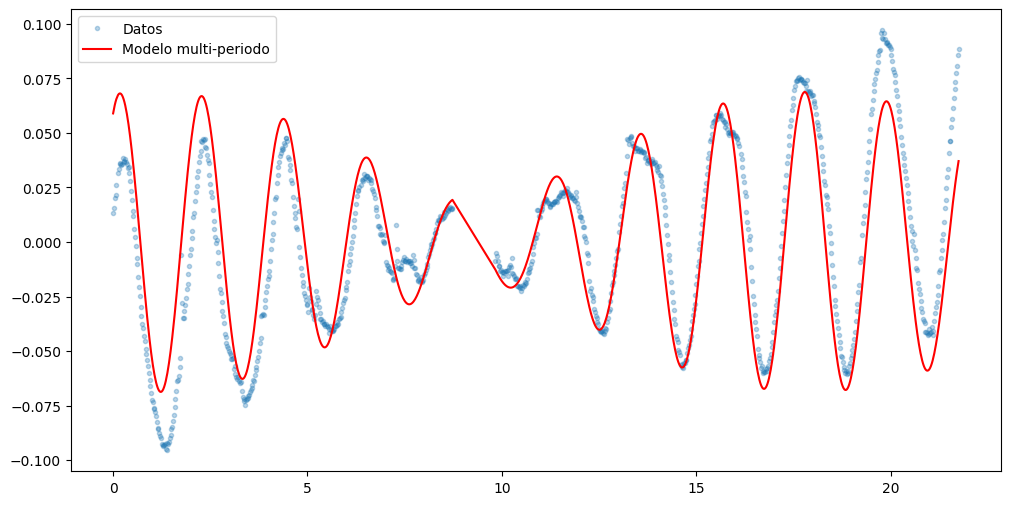

In [176]:
plt.figure(figsize=(12,6))
plt.plot(t, f, '.', alpha=0.3, label="Datos")
plt.plot(t, modelo_total, 'r', label="Modelo multi-periodo")
plt.legend()
plt.show()

In [177]:
T_beat = 1 / abs(f1 - f2)
print("Periodo de batido:", T_beat)

Periodo de batido: 16.949152542372993
